In [1]:
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [2]:
import seaborn as sns
iris = sns.load_dataset('iris')

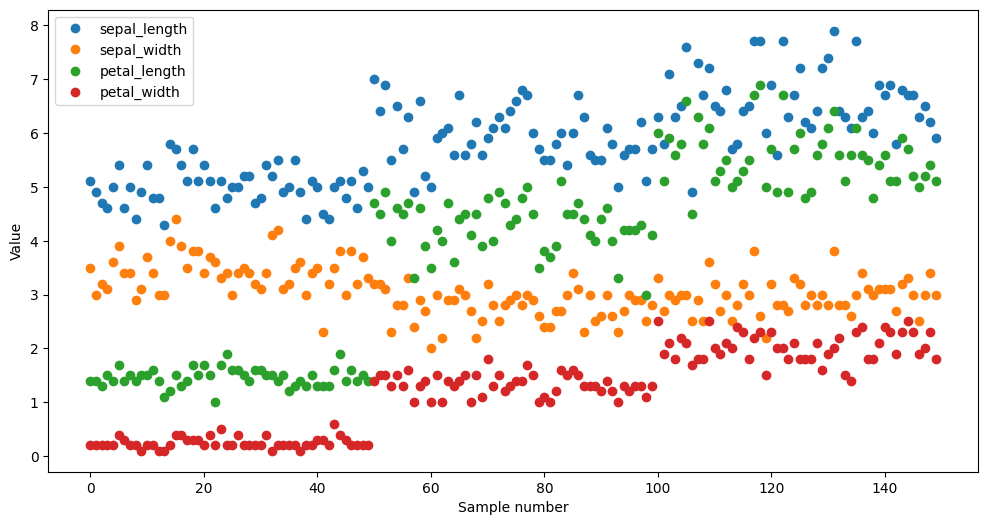

In [3]:
iris.plot(marker='o', linestyle='none', figsize=(12,6))
plt.xlabel('Sample number')
plt.ylabel('Value')
plt.show()

In [4]:
data = torch.tensor( iris[iris.columns[0:4]].values ) .float()

labels = torch.zeros(len(data), dtype=torch.long)

labels[iris.species=='versicolor'] = 1
labels[iris.species=='virginica'] = 2

In [16]:
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, train_size=.8)

train_data = TensorDataset(train_data, train_labels)
test_data = TensorDataset(test_data, test_labels)

batchsize = 16
train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [17]:
for X, y in train_loader:
    print(X.shape, y.shape)

torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([16, 4]) torch.Size([16])
torch.Size([8, 4]) torch.Size([8])


In [21]:
def createANewModel():

    ANNiris = nn.Sequential(
        nn.Linear(4,64),
        nn.ReLU(),
        nn.Linear(64,64),
        nn.ReLU(),
        nn.Linear(64,3)
    )

    lossfun = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(ANNiris.parameters(), lr=0.0005)

    return ANNiris, lossfun, optimizer

In [22]:
numepochs = 500

def trainTheModel():

    trainAcc = []
    testAcc = []
    losses = []

    for epochi in range(numepochs):

        batchAcc = []
        batchLoss = []
        for X, y in train_loader:

            yHat = ANNiris(X)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchAcc.append(100*torch.mean((torch.argmax(yHat, axis=1) == y).float()).item() )
            batchLoss.append( loss.item() )

        trainAcc.append( np.mean(batchAcc) )
        losses.append( np.mean(batchLoss) )

        X, y = next(iter(test_loader))
        predlabels = torch.argmax( ANNiris(X), axis=1 )
        testAcc.append(100*torch.mean((predlabels == y).float()).item() )

    return trainAcc, testAcc, losses

In [23]:
ANNiris, lossfun, optimizer = createANewModel()

trainAcc, testAcc, losses = trainTheModel()